In [ ]:
#====================================================
#
# IMPORTS
#
#====================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from google.colab.patches import cv2_imshow

In [ ]:
#====================================================
#
# CONFIGURATION
#
#====================================================

ACTIVE_CAMERAS = 2

RANSAC_THRESHOLD = 5.0

RANSAC_ITERATIONS = 2000

In [ ]:
#====================================================
#
# LOAD INPUT IMAGES
#
#====================================================

uploaded = files.upload()

Saving img2.jpeg to img2.jpeg
Saving img1.jpeg to img1.jpeg


In [ ]:
#====================================================
#
# FIX: sort the uploaded filenames.
#
# The CUDA notebook assigns cameras with
#     image_files = sorted(uploaded.keys())
# but this notebook used list(uploaded.keys()), whose
# order is whatever the upload widget returned. If the
# two orders differ, images[0]/images[1] are swapped
# relative to camera0/camera1 and every downstream
# result (H, warp, panorama) is wrong even though the
# matches themselves were fine.
#
#====================================================

image_names = sorted(uploaded.keys())

if len(image_names) != ACTIVE_CAMERAS:
    raise ValueError(
        f"Expected {ACTIVE_CAMERAS} images, "
        f"but received {len(image_names)}."
    )

images = []

for image_name in image_names:

    image = cv2.imread(image_name)

    if image is None:
        raise ValueError(
            f"Could not read {image_name}"
        )

    images.append(image)

print("Loaded Images (camera order):")

for i, (name, image) in enumerate(zip(image_names, images)):

    print(
        f"Camera {i} : {name}  {image.shape}"
    )


Loaded Images:
Camera 0 : (1280, 720, 3)
Camera 1 : (1280, 720, 3)


In [ ]:
#====================================================
#
# LOAD CUDA OUTPUT FILES
#
#====================================================

uploaded_cuda = files.upload()

Saving camera1_descriptors.txt to camera1_descriptors.txt
Saving matches.txt to matches.txt
Saving camera0_descriptors.txt to camera0_descriptors.txt


In [ ]:
cuda_output_files = list(
    uploaded_cuda.keys()
)

print("CUDA Files Loaded:")

for file_name in cuda_output_files:

    print(file_name)

CUDA Files Loaded:
camera1_descriptors.txt
matches.txt
camera0_descriptors.txt


In [ ]:
#====================================================
#
# READ CUDA DESCRIPTORS
#
#====================================================

def read_descriptors(
    file_name
):

    descriptors = []

    with open(file_name, "r") as file:

        total_descriptors = int(
            file.readline()
        )

        for _ in range(total_descriptors):

            values = file.readline().split()

            descriptor = {

                "x": int(values[0]),

                "y": int(values[1]),

                "octave": int(values[2]),

                "scale": int(values[3]),

                "angle": float(values[4])

            }

            descriptors.append(
                descriptor
            )

    return descriptors

In [ ]:
camera0_descriptors = read_descriptors(
    "camera0_descriptors.txt"
)

camera1_descriptors = read_descriptors(
    "camera1_descriptors.txt"
)

print(
    len(camera0_descriptors)
)

print(
    len(camera1_descriptors)
)

print()

print(
    camera0_descriptors[0]
)

print()

print(
    camera1_descriptors[0]
)

4250
4362

{'x': 420, 'y': 328, 'octave': 0, 'scale': 2, 'angle': 215.0}

{'x': 222, 'y': 295, 'octave': 0, 'scale': 1, 'angle': 325.0}


In [ ]:
#====================================================
#
# READ CUDA MATCHES
#
#====================================================

def read_matches(
    file_name
):

    matches = []

    with open(file_name, "r") as file:

        total_matches = int(
            file.readline()
        )

        for _ in range(total_matches):

            values = file.readline().split()

            match = {

                "query_index": int(values[0]),

                "train_index": int(values[1]),

                "distance": float(values[2]),

                "query_x": int(values[3]),

                "query_y": int(values[4]),

                "query_octave": int(values[5]),

                "train_x": int(values[6]),

                "train_y": int(values[7]),

                "train_octave": int(values[8])

            }

            matches.append(
                match
            )

    return matches

In [ ]:
cuda_matches = read_matches(
    "matches.txt"
)

print(
    "Total Matches :",
    len(cuda_matches)
)

print()

print(
    cuda_matches[0]
)

print()

print(
    cuda_matches[1]
)

Total Matches : 540

{'query_index': 4195, 'train_index': 3680, 'distance': 0.241993, 'query_x': 458, 'query_y': 191, 'query_octave': 0, 'train_x': 200, 'train_y': 259, 'train_octave': 0}

{'query_index': 4198, 'train_index': 4246, 'distance': 0.0758185, 'query_x': 337, 'query_y': 1086, 'query_octave': 0, 'train_x': 124, 'train_y': 1184, 'train_octave': 0}


In [ ]:
#====================================================
#
# CUDA -> CPU BRIDGE  (FIXED)
#
#====================================================
#
# FIX: octave coordinate scaling.
#
# The CUDA export writes keypoint (x, y) in OCTAVE
# coordinates (the downsampled image of that octave).
# The old bridge passed them to RANSAC unchanged, so a
# keypoint at octave 2 landed at 1/4 of its true
# position while octave 0 keypoints were correct.
# RANSAC was fed a mixture of coordinate frames ->
# garbage homography -> wrong warp / panorama.
#
# Every coordinate must be multiplied by 2**octave
# before any geometry is computed. (The match
# visualization in the CUDA notebook already does
# this: x1 = qx * (1 << qOct) - the same scaling was
# missing here.)
#
#====================================================

#------------------------------------------
# Camera 0 Keypoints  (full-resolution coords)
#------------------------------------------

kp1 = []

for descriptor in camera0_descriptors:

    scale_factor = 2 ** descriptor["octave"]

    kp1.append(
        (
            descriptor["x"] * scale_factor,
            descriptor["y"] * scale_factor,
            descriptor["octave"],
            descriptor["scale"],
            descriptor["angle"]
        )
    )

#------------------------------------------
# Camera 1 Keypoints  (full-resolution coords)
#------------------------------------------

kp2 = []

for descriptor in camera1_descriptors:

    scale_factor = 2 ** descriptor["octave"]

    kp2.append(
        (
            descriptor["x"] * scale_factor,
            descriptor["y"] * scale_factor,
            descriptor["octave"],
            descriptor["scale"],
            descriptor["angle"]
        )
    )

#------------------------------------------
# Matches
#
# NOTE: query_index / train_index are only
# valid against descriptor files exported by
# the SAME ./sift_stitcher run as matches.txt
# (GPU output order is nondeterministic).
# As a safety net we verify each match's
# embedded coordinates against the indexed
# keypoint; a mismatch means the files came
# from different runs.
#------------------------------------------

matches = []

stale_files = 0

for match in cuda_matches:

    qi = match["query_index"]
    ti = match["train_index"]

    q_scale = 2 ** match["query_octave"]
    t_scale = 2 ** match["train_octave"]

    expected_q = (
        match["query_x"] * q_scale,
        match["query_y"] * q_scale
    )

    expected_t = (
        match["train_x"] * t_scale,
        match["train_y"] * t_scale
    )

    if (
        qi >= len(kp1)
        or ti >= len(kp2)
        or kp1[qi][:2] != expected_q
        or kp2[ti][:2] != expected_t
    ):
        stale_files += 1
        continue

    matches.append(
        (
            qi,
            ti,
            match["distance"]
        )
    )

if stale_files > 0:
    print(
        f"WARNING: {stale_files} matches did not line up "
        "with the descriptor files - matches.txt and the "
        "camera*_descriptors.txt files must come from the "
        "same ./sift_stitcher run. Re-export all three "
        "files together."
    )

print("Bridge OK -", len(matches), "matches usable")


In [ ]:
print("Keypoints Camera 0 :", len(kp1))

print("Keypoints Camera 1 :", len(kp2))

print("Matches :", len(matches))

print()

print("First Keypoint Camera 0")

print(kp1[0])

print()

print("First Keypoint Camera 1")

print(kp2[0])

print()

print("First Match")

print(matches[0])

Keypoints Camera 0 : 4250
Keypoints Camera 1 : 4362
Matches : 540

First Keypoint Camera 0
(420, 328, 0, 2, 215.0)

First Keypoint Camera 1
(222, 295, 0, 1, 325.0)

First Match
(4195, 3680, 0.241993)


In [ ]:
# =====================================================
# REPROJECTION ERROR
# =====================================================

def reprojection_error(
    H,
    src_pt,
    dst_pt
):

    p = np.array([
        src_pt[0],
        src_pt[1],
        1.0
    ])

    projected = H @ p

    if abs(projected[2]) < 1e-10:
        return np.inf

    projected /= projected[2]

    error = np.linalg.norm(
        projected[:2]
        -
        dst_pt
    )

    return error

In [ ]:
H_identity = np.eye(3)

error = reprojection_error(

    H_identity,

    np.array([100,100]),

    np.array([100,100])

)

print(error)

0.0


In [ ]:
error = reprojection_error(

    H_identity,

    np.array([100,100]),

    np.array([110,100])

)

print(error)

10.0


In [ ]:
#====================================================
#
# Compute Homography (DLT)
#
#====================================================

import numpy as np

def compute_homography_dlt(
    src_pts,
    dst_pts
):
    """
    Compute homography using Direct Linear Transform.
    """

    if len(src_pts) < 4:
        raise ValueError(
            "At least 4 point correspondences are required."
        )

    A = []

    for (x, y), (u, v) in zip(
        src_pts,
        dst_pts
    ):

        A.append([
            -x,
            -y,
            -1,
             0,
             0,
             0,
             x * u,
             y * u,
             u
        ])

        A.append([
             0,
             0,
             0,
            -x,
            -y,
            -1,
             x * v,
             y * v,
             v
        ])

    A = np.array(
        A,
        dtype=np.float64
    )

    _, _, Vt = np.linalg.svd(A)

    H = Vt[-1].reshape(3, 3)

    H = H / H[2, 2]

    return H

In [ ]:
src_test = np.array(
    [
        [0, 0],
        [100, 0],
        [100, 100],
        [0, 100]
    ],
    dtype=np.float64
)

dst_test = np.array(
    [
        [10, 20],
        [110, 20],
        [110, 120],
        [10, 120]
    ],
    dtype=np.float64
)

H_test = compute_homography_dlt(
    src_test,
    dst_test
)

print("Homography Shape :", H_test.shape)
print()
print(H_test)
print()
print("Determinant :", np.linalg.det(H_test))

Homography Shape : (3, 3)

[[ 1.00000000e+00 -3.83182845e-15  1.00000000e+01]
 [-5.19875927e-14  1.00000000e+00  2.00000000e+01]
 [-1.09928590e-15  2.80110336e-16  1.00000000e+00]]

Determinant : 0.9999999999998356


In [ ]:
#====================================================
#
# Validate CUDA Bridge
#
#====================================================

invalid_matches = 0

for i, match in enumerate(matches):

    query_index = match[0]

    train_index = match[1]

    if query_index >= len(kp1):

        print(
            "Invalid Query Index :",
            query_index
        )

        invalid_matches += 1

    if train_index >= len(kp2):

        print(
            "Invalid Train Index :",
            train_index
        )

        invalid_matches += 1

print()

print(
    "Total Matches :",
    len(matches)
)

print(
    "Invalid Matches :",
    invalid_matches
)


Total Matches : 540
Invalid Matches : 0


In [ ]:
#====================================================
#
# Custom RANSAC Filter
#
#====================================================

import random

def custom_ransac_filter(

    kp1,

    kp2,

    matches,

    iterations=2000,

    threshold=5.0
):

    best_H = None

    best_inliers = []

    best_inlier_count = 0

    if len(matches) < 4:

        print(
            "Not enough matches for RANSAC."
        )

        return [], None

    for iteration in range(iterations):

        sample = random.sample(
            matches,
            4
        )

        try:

            src_pts = np.array(
                [
                    kp1[m[0]][:2]
                    for m in sample
                ]
            )

            dst_pts = np.array(
                [
                    kp2[m[1]][:2]
                    for m in sample
                ]
            )

            H = compute_homography_dlt(

                src_pts,

                dst_pts
            )

        except np.linalg.LinAlgError:

            continue

        current_inliers = []

        for match in matches:

            query_index = match[0]

            train_index = match[1]

            src_point = np.array(
                kp1[
                    query_index
                ][:2]
            )

            dst_point = np.array(
                kp2[
                    train_index
                ][:2]
            )

            error = reprojection_error(

                H,

                src_point,

                dst_point
            )

            if error < threshold:

                current_inliers.append(

                    (
                        query_index,

                        train_index,

                        error
                    )

                )

        if len(current_inliers) > best_inlier_count:

            best_inlier_count = len(
                current_inliers
            )

            best_inliers = current_inliers

            best_H = H

    print(
        "Best Inliers :",
        best_inlier_count
    )

    print(
        "Total Matches :",
        len(matches)
    )

    return best_inliers, best_H

In [ ]:
#====================================================
#
# Run Custom RANSAC
#
#====================================================

inlier_matches, homography = custom_ransac_filter(

    kp1,

    kp2,

    matches
)

print()

print(
    "Inliers :",
    len(inlier_matches)
)

print()

print(
    "Homography :"
)

print(homography)

Best Inliers : 342
Total Matches : 540

Inliers : 342

Homography :
[[ 1.18473696e+00  5.11423016e-02 -3.25908063e+02]
 [ 1.51440413e-01  1.06529032e+00  2.14434680e+01]
 [ 3.23334887e-04 -6.47632088e-05  1.00000000e+00]]


In [ ]:
import time

start = time.time()

inlier_matches, homography = custom_ransac_filter(
    kp1,
    kp2,
    matches
)

end = time.time()

print(f"RANSAC Time : {end - start:.3f} seconds")

Best Inliers : 342
Total Matches : 540
RANSAC Time : 17.097 seconds


In [ ]:
#====================================================
#
# Refine Homography
#
#====================================================

def refine_homography(

    kp1,

    kp2,

    inliers

):

    src_pts = np.array(
        [
            kp1[i][:2]
            for i, j, d in inliers
        ]
    )

    dst_pts = np.array(
        [
            kp2[j][:2]
            for i, j, d in inliers
        ]
    )

    refined_homography = compute_homography_dlt(

        src_pts,

        dst_pts
    )

    return refined_homography

In [ ]:
#====================================================
#
# Test Refined Homography
#
#====================================================

refined_homography = refine_homography(

    kp1,

    kp2,

    inlier_matches
)

print(
    "Refined Homography Shape :",
    refined_homography.shape
)

print()

print(
    refined_homography
)

Refined Homography Shape : (3, 3)

[[ 1.19211155e+00  4.92160212e-02 -3.27423105e+02]
 [ 1.58274928e-01  1.06583605e+00  1.84314972e+01]
 [ 3.33459246e-04 -6.89460921e-05  1.00000000e+00]]


In [ ]:
#====================================================
#
# Average Reprojection Error
#
#====================================================

def average_reprojection_error(

    homography,

    kp1,

    kp2,

    inlier_matches

):

    reprojection_errors = []

    for query_index, train_index, distance in inlier_matches:

        source_point = np.array(

            kp1[
                query_index
            ][:2]

        )

        destination_point = np.array(

            kp2[
                train_index
            ][:2]

        )

        reprojection_errors.append(

            reprojection_error(

                homography,

                source_point,

                destination_point

            )

        )

    return np.mean(
        reprojection_errors
    )

In [ ]:
#====================================================
#
# Test Average Reprojection Error
#
#====================================================

average_error = average_reprojection_error(

    refined_homography,

    kp1,

    kp2,

    inlier_matches

)

print()

print(
    "Average Reprojection Error :",
    average_error
)


Average Reprojection Error : 0.7925077562004961


In [ ]:
#====================================================
#
# Symmetric Reprojection Error
#
#====================================================

def symmetric_reprojection_error(

    homography,

    source_point,

    destination_point

):

    inverse_homography = np.linalg.inv(

        homography

    )

    #------------------------------------------
    # Forward Projection
    #------------------------------------------

    source_homogeneous = np.array(

        [

            source_point[0],

            source_point[1],

            1.0

        ]

    )

    projected_destination = (

        homography @

        source_homogeneous

    )

    projected_destination /= (

        projected_destination[2]

    )

    forward_error = np.linalg.norm(

        projected_destination[:2]

        -

        destination_point

    )

    #------------------------------------------
    # Backward Projection
    #------------------------------------------

    destination_homogeneous = np.array(

        [

            destination_point[0],

            destination_point[1],

            1.0

        ]

    )

    projected_source = (

        inverse_homography @

        destination_homogeneous

    )

    projected_source /= (

        projected_source[2]

    )

    backward_error = np.linalg.norm(

        projected_source[:2]

        -

        source_point

    )

    return (

        forward_error

        +

        backward_error

    )

In [ ]:
#====================================================
#
# Test Symmetric Error
#
#====================================================

query_index, train_index, _ = inlier_matches[0]

source_point = np.array(

    kp1[
        query_index
    ][:2]

)

destination_point = np.array(

    kp2[
        train_index
    ][:2]

)

symmetry_error = symmetric_reprojection_error(

    refined_homography,

    source_point,

    destination_point

)

print(

    "Symmetric Error :",

    symmetry_error

)


Symmetric Error : 1.1807430913542578


In [ ]:
#====================================================
#
# Average Symmetric Reprojection Error
#
#====================================================

def average_symmetric_error(

    homography,

    kp1,

    kp2,

    inlier_matches

):

    symmetric_errors = []

    for query_index, train_index, distance in inlier_matches:

        source_point = np.array(

            kp1[
                query_index
            ][:2]

        )

        destination_point = np.array(

            kp2[
                train_index
            ][:2]

        )

        current_error = symmetric_reprojection_error(

            homography,

            source_point,

            destination_point

        )

        symmetric_errors.append(

            current_error

        )

    return np.mean(

        symmetric_errors

    )

In [ ]:
#====================================================
#
# Test Average Symmetric Error
#
#====================================================

average_symmetry_error = average_symmetric_error(

    refined_homography,

    kp1,

    kp2,

    inlier_matches

)

print()

print(

    "Average Symmetric Error :",

    average_symmetry_error

)


Average Symmetric Error : 1.574825079888507


In [ ]:
#====================================================
#
# Error Statistics
#
#====================================================

def calculate_error_statistics(

    homography,

    kp1,

    kp2,

    inlier_matches

):

    reprojection_errors = []

    symmetric_errors = []

    for (

        query_index,

        train_index,

        distance

    ) in inlier_matches:

        source_point = np.array(

            kp1[
                query_index
            ][:2]

        )

        destination_point = np.array(

            kp2[
                train_index
            ][:2]

        )

        reprojection_errors.append(

            reprojection_error(

                homography,

                source_point,

                destination_point

            )

        )

        symmetric_errors.append(

            symmetric_reprojection_error(

                homography,

                source_point,

                destination_point

            )

        )

    reprojection_errors = np.array(

        reprojection_errors

    )

    symmetric_errors = np.array(

        symmetric_errors

    )

    statistics = {

        "min_reprojection":

            np.min(
                reprojection_errors
            ),

        "max_reprojection":

            np.max(
                reprojection_errors
            ),

        "mean_reprojection":

            np.mean(
                reprojection_errors
            ),

        "median_reprojection":

            np.median(
                reprojection_errors
            ),

        "min_symmetric":

            np.min(
                symmetric_errors
            ),

        "max_symmetric":

            np.max(
                symmetric_errors
            ),

        "mean_symmetric":

            np.mean(
                symmetric_errors
            ),

        "median_symmetric":

            np.median(
                symmetric_errors
            )

    }

    return statistics

In [ ]:
#====================================================
#
# Verify Error Statistics
#
#====================================================

error_statistics = calculate_error_statistics(

    refined_homography,

    kp1,

    kp2,

    inlier_matches

)

print()

for key, value in error_statistics.items():

    print(

        f"{key:25s} : {value:.6f}"
    )


min_reprojection          : 0.062781
max_reprojection          : 2.962453
mean_reprojection         : 0.792508
median_reprojection       : 0.715258
min_symmetric             : 0.124072
max_symmetric             : 5.956734
mean_symmetric            : 1.574825
median_symmetric          : 1.462427


In [ ]:
#====================================================
#
# Bilinear Sampling
#
#====================================================

def bilinear_sample(

    image,

    x,

    y

):

    image_height, image_width = image.shape[:2]

    if (

        x < 0 or

        x >= image_width - 1 or

        y < 0 or

        y >= image_height - 1

    ):

        return np.zeros(

            3,

            dtype=np.float32

        )

    x0 = int(

        np.floor(x)

    )

    y0 = int(

        np.floor(y)

    )

    x1 = x0 + 1

    y1 = y0 + 1

    dx = x - x0

    dy = y - y0

    top = (

        (1.0 - dx)

        * image[y0, x0]

        +

        dx

        * image[y0, x1]

    )

    bottom = (

        (1.0 - dx)

        * image[y1, x0]

        +

        dx

        * image[y1, x1]

    )

    interpolated_pixel = (

        (1.0 - dy)

        * top

        +

        dy

        * bottom

    )

    return interpolated_pixel.astype(

        np.float32

    )

In [ ]:
#====================================================
#
# Test Bilinear Sampling
#
#====================================================

sample_pixel = bilinear_sample(

    images[0],

    150.4,

    200.7

)

print()

print(

    "Interpolated Pixel :"

)

print(

    sample_pixel

)


Interpolated Pixel :
[250.34 219.74 184.74]


In [ ]:
#====================================================
#
# Inverse Warp
#
#====================================================

def inverse_warp(

    source_image,

    homography,

    output_width,

    output_height

):

    warped_image = np.zeros(

        (

            output_height,

            output_width,

            3

        ),

        dtype=np.uint8

    )

    #--------------------------------------------------
    #
    # Compute Inverse Homography
    #
    #--------------------------------------------------

    inverse_homography = np.linalg.inv(

        homography

    )

    #--------------------------------------------------
    #
    # Traverse Every Pixel Of Output Canvas
    #
    #--------------------------------------------------

    for output_y in range(output_height):

        for output_x in range(output_width):

            #------------------------------------------
            #
            # Convert Output Pixel To Homogeneous Form
            #
            #------------------------------------------

            output_point = np.array(

                [

                    output_x,

                    output_y,

                    1.0

                ],

                dtype=np.float64

            )

            #------------------------------------------
            #
            # Project Back Into Source Image
            #
            #------------------------------------------

            source_point = (

                inverse_homography @ output_point

            )

            source_point /= source_point[2]

            source_x = source_point[0]

            source_y = source_point[1]

            #------------------------------------------
            #
            # Check Whether Source Point Is Inside Image
            #
            #------------------------------------------

            source_height, source_width = source_image.shape[:2]

            if (

                source_x < 0 or

                source_x >= source_width - 1 or

                source_y < 0 or

                source_y >= source_height - 1

            ):

                continue

            #------------------------------------------
            #
            # Sample Source Image
            #
            #------------------------------------------

            sampled_pixel = bilinear_sample(

                source_image,

                source_x,

                source_y

            )

            #------------------------------------------
            #
            # Store Pixel In Warped Image
            #
            #------------------------------------------

            warped_image[

                output_y,

                output_x

            ] = sampled_pixel

    return warped_image

In [ ]:
test_warp = inverse_warp(

    images[0],

    refined_homography,

    500,

    400

)

print(

    test_warp.shape
)

(400, 500, 3)


In [ ]:
#====================================================
#
# Test Inverse Warp
#
#====================================================

warped_image = inverse_warp(

    images[0],

    refined_homography,

    images[0].shape[1],

    images[0].shape[0]

)

print(

    "Warped Image Shape :",

    warped_image.shape
)

Warped Image Shape : (1280, 720, 3)


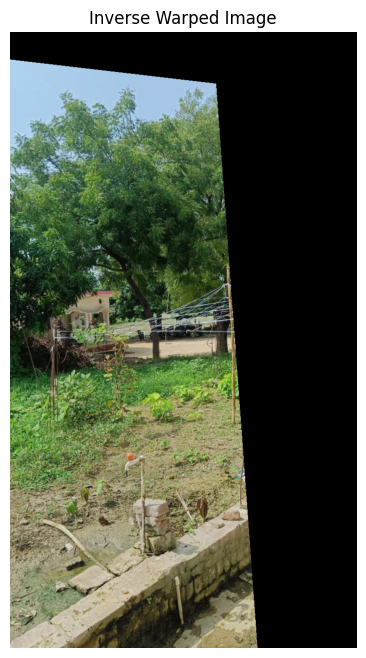

In [ ]:
#====================================================
#
# Visualize Warped Image
#
#====================================================

plt.figure(figsize=(10,8))

plt.imshow(

    cv2.cvtColor(

        warped_image,

        cv2.COLOR_BGR2RGB

    )

)

plt.title(

    "Inverse Warped Image"

)

plt.axis("off")

plt.show()

In [ ]:
#====================================================
#
# Transform Image Corners
#
#====================================================

def transform_image_corners(

    image,

    homography

):

    image_height, image_width = image.shape[:2]

    corners = np.array(

        [

            [0, 0],

            [image_width - 1, 0],

            [image_width - 1, image_height - 1],

            [0, image_height - 1]

        ],

        dtype=np.float64

    )

    transformed_corners = []

    for x, y in corners:

        point = np.array(

            [

                x,

                y,

                1.0

            ],

            dtype=np.float64

        )

        transformed = homography @ point

        transformed /= transformed[2]

        transformed_corners.append(

            transformed[:2]

        )

    return np.array(

        transformed_corners
    )

In [ ]:
transformed_corners = transform_image_corners(

    images[0],

    refined_homography

)

print("Transformed Corners:\n")

print(transformed_corners)

Transformed Corners:

[[-327.42310546   18.43149718]
 [ 427.2651932   106.65892541]
 [ 514.64499889 1298.59999525]
 [-290.05331045 1515.25401375]]


In [ ]:
#====================================================
#
# Compute Panorama Canvas
#
#====================================================

def compute_panorama_canvas(

    transformed_corners,

    reference_image

):

    reference_height, reference_width = (

        reference_image.shape[:2]

    )

    #------------------------------------------
    #
    # X Coordinates
    #
    #------------------------------------------

    x_coordinates = np.append(

        transformed_corners[:, 0],

        [

            0,

            reference_width

        ]

    )

    #------------------------------------------
    #
    # Y Coordinates
    #
    #------------------------------------------

    y_coordinates = np.append(

        transformed_corners[:, 1],

        [

            0,

            reference_height

        ]

    )

    #------------------------------------------
    #
    # Panorama Bounds
    #
    #------------------------------------------

    minimum_x = np.floor(

        np.min(x_coordinates)

    ).astype(int)

    maximum_x = np.ceil(

        np.max(x_coordinates)

    ).astype(int)

    minimum_y = np.floor(

        np.min(y_coordinates)

    ).astype(int)

    maximum_y = np.ceil(

        np.max(y_coordinates)

    ).astype(int)

    #------------------------------------------
    #
    # Panorama Size
    #
    #------------------------------------------

    panorama_width = (

        maximum_x -

        minimum_x

    )

    panorama_height = (

        maximum_y -

        minimum_y

    )

    #------------------------------------------
    #
    # Translation Offset
    #
    #------------------------------------------

    translation_x = -minimum_x

    translation_y = -minimum_y

    return (

        panorama_width,

        panorama_height,

        translation_x,

        translation_y

    )

In [ ]:
panorama_width, panorama_height, translation_x, translation_y = (

    compute_panorama_canvas(

        transformed_corners,

        images[1]

    )

)

print()

print(

    "Panorama Width :",

    panorama_width

)

print(

    "Panorama Height :",

    panorama_height

)

print(

    "Translation X :",

    translation_x

)

print(

    "Translation Y :",

    translation_y

)


Panorama Width : 1048
Panorama Height : 1516
Translation X : 328
Translation Y : 0


In [ ]:
#====================================================
#
# Build Translation Matrix
#
#====================================================

def build_translation_matrix(

    translation_x,

    translation_y

):

    translation_matrix = np.array(

        [

            [1.0, 0.0, translation_x],

            [0.0, 1.0, translation_y],

            [0.0, 0.0, 1.0]

        ],

        dtype=np.float64

    )

    return translation_matrix

In [ ]:
translation_matrix = build_translation_matrix(

    translation_x,

    translation_y

)

print()

print(

    translation_matrix

)


[[  1.   0. 328.]
 [  0.   1.   0.]
 [  0.   0.   1.]]


In [ ]:
#====================================================
#
# Build Panorama Homography
#
#====================================================

panorama_homography = (

    translation_matrix @

    refined_homography

)

print()

print(

    "Panorama Homography :"

)

print(

    panorama_homography

)


Panorama Homography :
[[ 1.30148618e+00  2.66017029e-02  5.76894538e-01]
 [ 1.58274928e-01  1.06583605e+00  1.84314972e+01]
 [ 3.33459246e-04 -6.89460921e-05  1.00000000e+00]]


In [ ]:
print()

print(

    "Shape :",

    panorama_homography.shape

)

print()

print(

    "Determinant :",

    np.linalg.det(

        panorama_homography

    )

)


Shape : (3, 3)

Determinant : 1.3845665788376387


In [ ]:
#====================================================
#
# Warp Image Into Panorama Canvas
#
#====================================================
#
# FIX: warp images[0], not images[1].
#
# refined_homography maps camera-0 points -> camera-1
# points (RANSAC used src=kp1, dst=kp2). So images[0]
# is the image that gets warped, and images[1] is the
# reference that is only translated into place.
#
# The old code warped images[1] here AND placed
# images[1] as the reference below, so images[0]
# never appeared in the panorama at all: the output
# was image 1 blended with a slightly rotated copy of
# itself. That is exactly the "one image, sheared,
# with black corners" result.
#
# Everything else in the chain already assumes
# images[0] is the source:
#   cell 38 : corners of images[0] transformed by H
#   cell 40 : canvas = those corners + images[1] extent
#   cell 48 : images[1] placed as reference
#
#====================================================

warped_panorama_image = inverse_warp(

    images[0],

    panorama_homography,

    panorama_width,

    panorama_height

)

print()

print(

    "Warped Panorama Shape :",

    warped_panorama_image.shape

)


Warped Panorama Shape : (1516, 1048, 3)


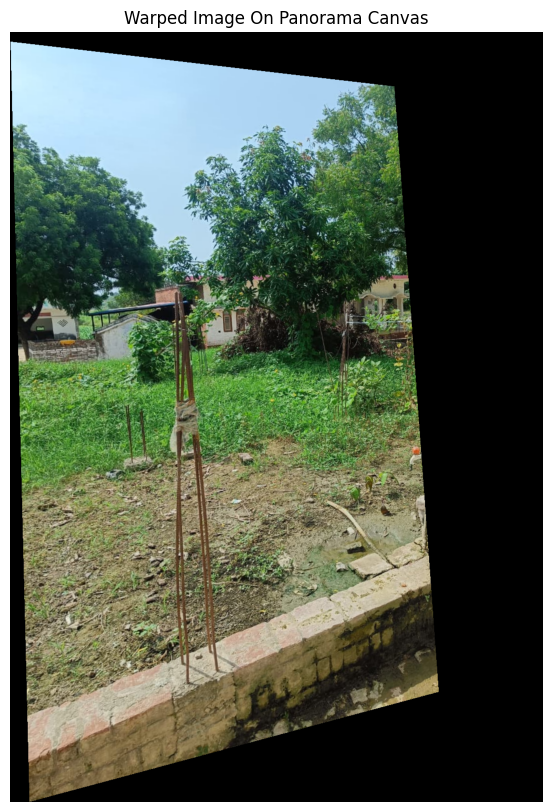

In [ ]:
#====================================================
#
# Visualize Warped Panorama
#
#====================================================

plt.figure(

    figsize=(10,10)

)

plt.imshow(

    cv2.cvtColor(

        warped_panorama_image,

        cv2.COLOR_BGR2RGB

    )

)

plt.title(

    "Warped Image On Panorama Canvas"

)

plt.axis("off")

plt.show()

In [ ]:
#====================================================
#
# Place Reference Image
#
#====================================================

def place_reference_image(

    reference_image,

    panorama_width,

    panorama_height,

    translation_x,

    translation_y

):

    reference_panorama = np.zeros(

        (

            panorama_height,

            panorama_width,

            3

        ),

        dtype=np.uint8

    )

    #--------------------------------------------------
    #
    # Traverse Reference Image
    #
    #--------------------------------------------------

    reference_height, reference_width = (

        reference_image.shape[:2]

    )

    for reference_y in range(

        reference_height

    ):

        for reference_x in range(

            reference_width

        ):

            #------------------------------------------
            #
            # Compute Panorama Coordinates
            #
            #------------------------------------------

            panorama_x = (

                reference_x +

                translation_x

            )

            panorama_y = (

                reference_y +

                translation_y

            )

            #------------------------------------------
            #
            # Copy Pixel Into Panorama
            #
            #------------------------------------------

            reference_panorama[

                panorama_y,

                panorama_x

            ] = reference_image[

                reference_y,

                reference_x

            ]

    return reference_panorama


In [ ]:
reference_panorama = place_reference_image(

    images[1],

    panorama_width,

    panorama_height,

    translation_x,

    translation_y

)

print(

    reference_panorama.shape
)

(1516, 1048, 3)


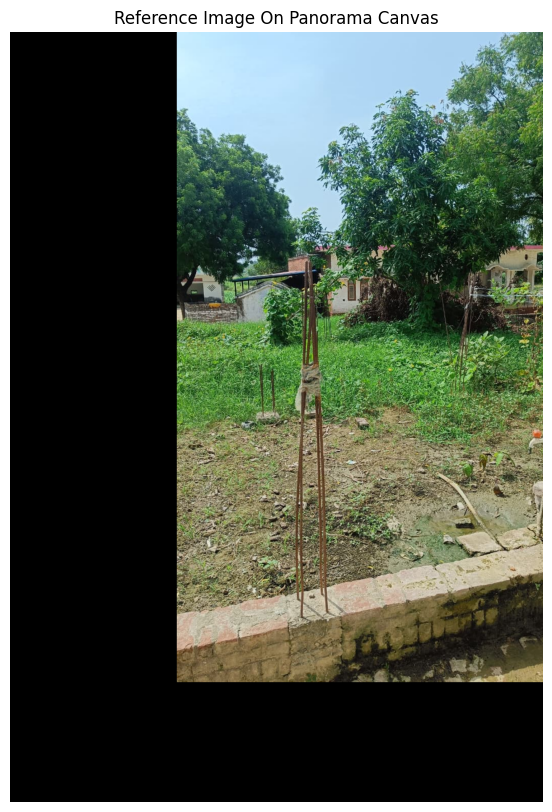

In [ ]:
#====================================================
#
# Visualize Reference Panorama
#
#====================================================

plt.figure(

    figsize=(10,10)

)

plt.imshow(

    cv2.cvtColor(

        reference_panorama,

        cv2.COLOR_BGR2RGB

    )

)

plt.title(

    "Reference Image On Panorama Canvas"

)

plt.axis("off")

plt.show()

In [ ]:
#====================================================
#
# Create Valid Mask
#
#====================================================

def create_valid_mask(

    image

):

    valid_mask = np.any(

        image != 0,

        axis=2

    )

    return valid_mask.astype(

        np.uint8

    )


In [ ]:
warped_mask = create_valid_mask(

    warped_panorama_image

)

reference_mask = create_valid_mask(

    reference_panorama

)

print(

    warped_mask.shape

)

print(

    reference_mask.shape
)

(1516, 1048)
(1516, 1048)


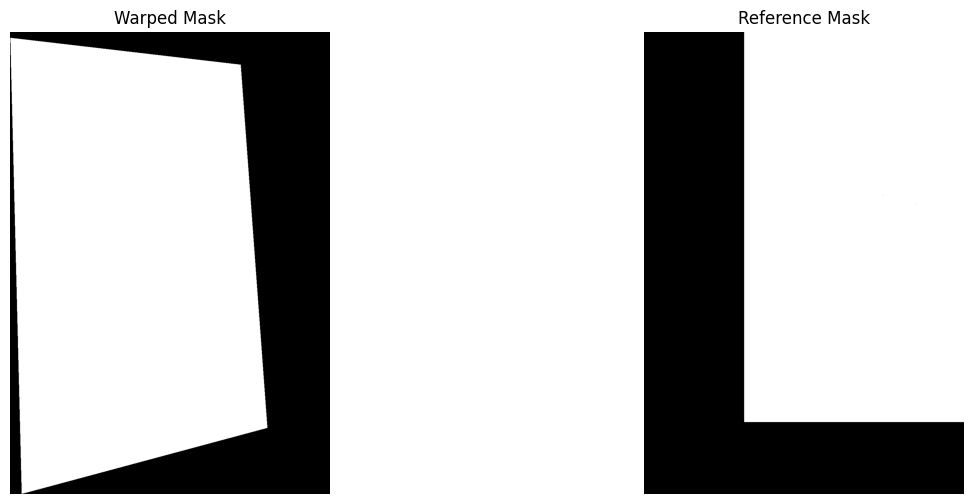

In [ ]:
#====================================================
#
# Visualize Masks
#
#====================================================

plt.figure(

    figsize=(15,6)

)

plt.subplot(

    1,

    2,

    1

)

plt.imshow(

    warped_mask,

    cmap="gray"

)

plt.title(

    "Warped Mask"

)

plt.axis("off")

plt.subplot(

    1,

    2,

    2

)

plt.imshow(

    reference_mask,

    cmap="gray"

)

plt.title(

    "Reference Mask"

)

plt.axis("off")

plt.show()

In [ ]:
print()

print(
    "Warped Valid Pixels :",
    np.sum(warped_mask)
)

print()

print(
    "Reference Valid Pixels :",
    np.sum(reference_mask)
)


Warped Valid Pixels : 1052225

Reference Valid Pixels : 921598


In [ ]:
#====================================================
#
# Compute Distance Transform
#
#====================================================

def compute_distance_transform(

    valid_mask

):

    distance_map = cv2.distanceTransform(

        valid_mask,

        cv2.DIST_L2,

        3

    )

    return distance_map

In [ ]:
warped_distance = compute_distance_transform(

    warped_mask

)

reference_distance = compute_distance_transform(

    reference_mask

)

print()

print(

    warped_distance.shape

)

print(

    reference_distance.shape
)


(1516, 1048)
(1516, 1048)


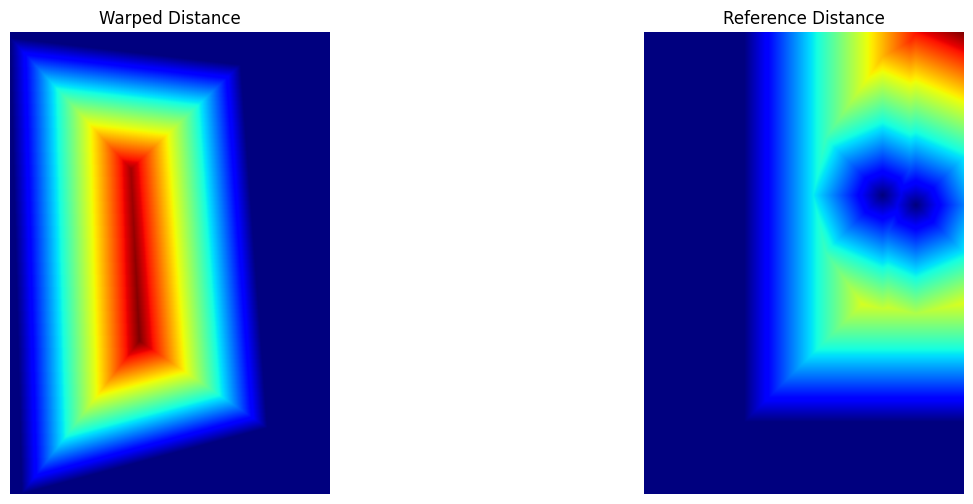

In [ ]:
#====================================================
#
# Visualize Distance Transform
#
#====================================================

plt.figure(

    figsize=(15,6)

)

plt.subplot(

    1,

    2,

    1

)

plt.imshow(

    warped_distance,

    cmap="jet"

)

plt.title(

    "Warped Distance"

)

plt.axis("off")

plt.subplot(

    1,

    2,

    2

)

plt.imshow(

    reference_distance,

    cmap="jet"

)

plt.title(

    "Reference Distance"

)

plt.axis("off")

plt.show()

In [ ]:
#====================================================
#
# Compute Normalized Weight Maps
#
#====================================================

def compute_weight_maps(

    warped_distance,

    reference_distance

):

    epsilon = 1e-8

    total_distance = (

        warped_distance +

        reference_distance +

        epsilon

    )

    warped_weight = (

        warped_distance /

        total_distance

    )

    reference_weight = (

        reference_distance /

        total_distance

    )

    return (

        warped_weight,

        reference_weight

    )

In [ ]:
warped_weight, reference_weight = (

    compute_weight_maps(

        warped_distance,

        reference_distance

    )

)

print()

print(

    warped_weight.shape

)

print(

    reference_weight.shape

)


(1516, 1048)
(1516, 1048)


In [ ]:
#====================================================
#
# Verify Weight Maps
#
#====================================================

print()

print(

    "Minimum Weight :",

    np.min(warped_weight)

)


print(

    "Maximum Weight :",

    np.max(warped_weight)

)


valid_region = (

    warped_mask |

    reference_mask

).astype(bool)

weight_error = np.max(

    np.abs(

        (

            warped_weight +

            reference_weight

        )[valid_region]

        -

        1.0

    )

)

print()

print(

    "Weight Sum Error :",

    weight_error

)


Minimum Weight : 0.0
Maximum Weight : 1.0

Weight Sum Error : 1.1920929e-07


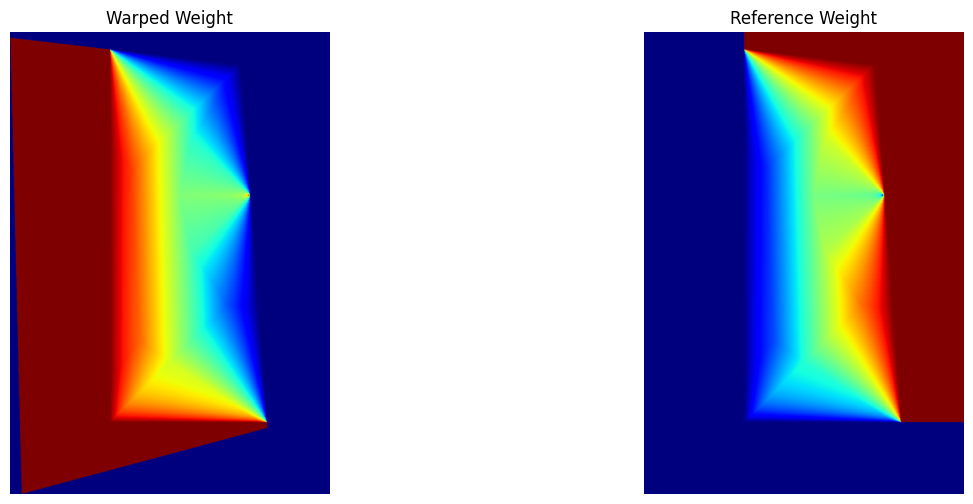

In [ ]:
#====================================================
#
# Visualize Weight Maps
#
#====================================================

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)

plt.imshow(

    warped_weight,

    cmap="jet"

)

plt.title(

    "Warped Weight"

)

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(

    reference_weight,

    cmap="jet"

)

plt.title(

    "Reference Weight"

)

plt.axis("off")

plt.show()

In [ ]:
print()

print(
    "Warp Weight"
)

print(
    np.min(warped_weight),
    np.max(warped_weight)
)

print()

print(
    "Reference Weight"
)

print(
    np.min(reference_weight),
    np.max(reference_weight)
)


Warp Weight
0.0 1.0

Reference Weight
0.0 1.0


In [ ]:
print()

print(
    np.isnan(warped_weight).sum()
)

print(
    np.isnan(reference_weight).sum()
)


0
0


In [ ]:
#====================================================
#
# Weighted Blend
#
#====================================================

def weighted_blend(

    warped_panorama,

    reference_panorama,

    warped_weight,

    reference_weight

):

    blended_panorama = np.zeros_like(

        warped_panorama

    )

      #--------------------------------------------------
    #
    # Traverse Panorama
    #
    #--------------------------------------------------

    panorama_height, panorama_width = (

        blended_panorama.shape[:2]

    )

    for panorama_y in range(

        panorama_height

    ):

        for panorama_x in range(

            panorama_width

        ):

            #------------------------------------------
            #
            # Weighted Blend
            #
            #------------------------------------------

            blended_panorama[

                panorama_y,

                panorama_x

            ] = (

                warped_weight[

                    panorama_y,

                    panorama_x

                ] *

                warped_panorama[

                    panorama_y,

                    panorama_x

                ].astype(np.float32)

                +

                reference_weight[

                    panorama_y,

                    panorama_x

                ] *

                reference_panorama[

                    panorama_y,

                    panorama_x

                ].astype(np.float32)

            ).astype(

                np.uint8

            )

    return blended_panorama

In [ ]:
blended_panorama = weighted_blend(

    warped_panorama_image,

    reference_panorama,

    warped_weight,

    reference_weight

)

print(

    blended_panorama.shape
)

(1516, 1048, 3)


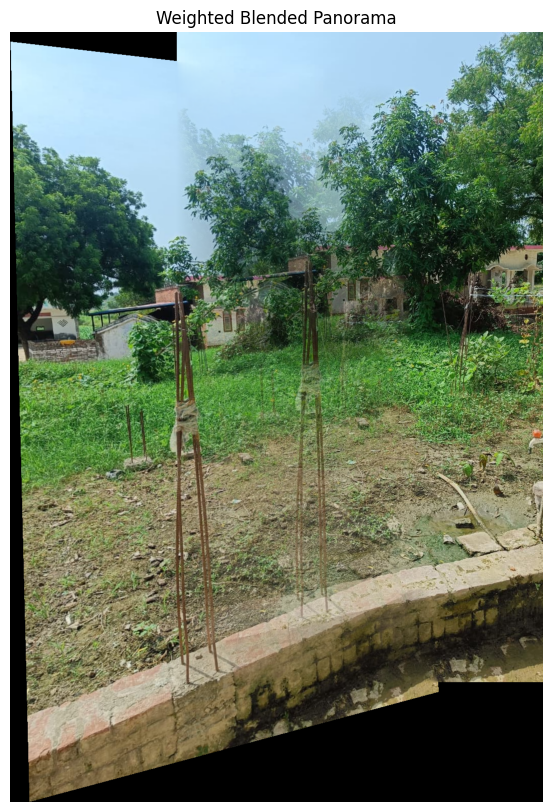

In [ ]:
#====================================================
#
# Visualize Blended Panorama
#
#====================================================

plt.figure(

    figsize=(12,10)

)

plt.imshow(

    cv2.cvtColor(

        blended_panorama,

        cv2.COLOR_BGR2RGB

    )

)

plt.title(

    "Weighted Blended Panorama"

)

plt.axis("off")

plt.show()

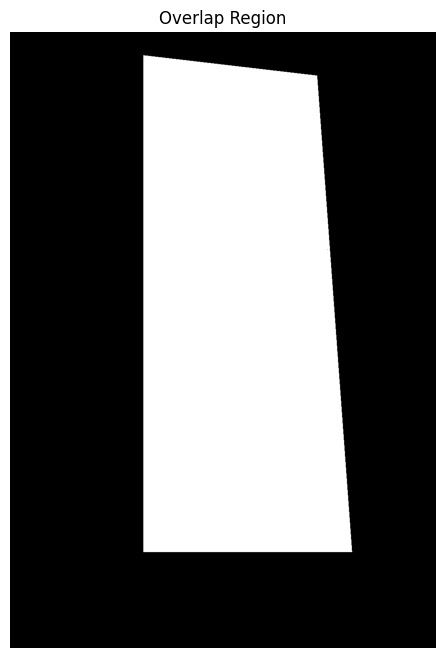

In [ ]:
overlap = warped_mask & reference_mask

plt.figure(figsize=(8,8))
plt.imshow(overlap, cmap="gray")
plt.title("Overlap Region")
plt.axis("off")
plt.show()

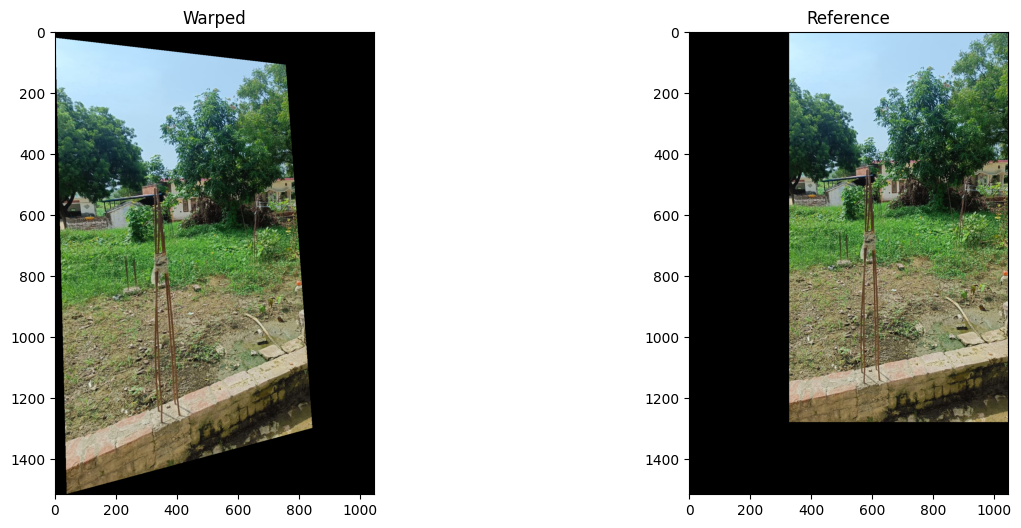

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(warped_panorama_image, cv2.COLOR_BGR2RGB))
plt.title("Warped")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(reference_panorama, cv2.COLOR_BGR2RGB))
plt.title("Reference")

plt.show()

In [ ]:
print("Image 0 shape :", images[0].shape)
print("Image 1 shape :", images[1].shape)

print()

print("Camera0")

print(
    "x :",
    min(k["x"] for k in kp1),
    max(k["x"] for k in kp1)
)

print(
    "y :",
    min(k["y"] for k in kp1),
    max(k["y"] for k in kp1)
)

print()

print("Camera1")

print(
    "x :",
    min(k["x"] for k in kp2),
    max(k["x"] for k in kp2)
)

print(
    "y :",
    min(k["y"] for k in kp2),
    max(k["y"] for k in kp2)
)

Image 0 shape : (1280, 720, 3)
Image 1 shape : (1280, 720, 3)

Camera0


TypeError: tuple indices must be integers or slices, not str

In [ ]:
print(type(kp1))

print(type(kp1[0]))

print()

print(kp1[0])

print()

print(kp1[1])

<class 'list'>
<class 'tuple'>

(420, 328, 0, 2, 215.0)

(688, 568, 0, 2, 215.0)


In [ ]:
print()

print("Image 0 shape :", images[0].shape)

print("Image 1 shape :", images[1].shape)

print()

print("Camera0")

print(
    "x :",
    min(k[0] for k in kp1),
    max(k[0] for k in kp1)
)

print(
    "y :",
    min(k[1] for k in kp1),
    max(k[1] for k in kp1)
)

print()

print("Camera1")

print(
    "x :",
    min(k[0] for k in kp2),
    max(k[0] for k in kp2)
)

print(
    "y :",
    min(k[1] for k in kp2),
    max(k[1] for k in kp2)
)


Image 0 shape : (1280, 720, 3)
Image 1 shape : (1280, 720, 3)

Camera0
x : 1 718
y : 5 1278

Camera1
x : 3 718
y : 14 1278


In [ ]:
print()

print("Camera0 Octaves")

print(sorted(set(k[2] for k in kp1)))

print()

print("Camera1 Octaves")

print(sorted(set(k[2] for k in kp2)))


Camera0 Octaves
[0, 1, 2, 3]

Camera1 Octaves
[0, 1, 2, 3]
